In [1]:
!sudo apt update
!sudo apt install postgresql postgresql-contrib -y
!sudo service postgresql start

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [75.2 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,604 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,696 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,842 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,243 kB]
Hit:10 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,788 kB]
Hit:13 http://archiv

In [2]:
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"
!sudo -u postgres createdb mentaldb

ALTER ROLE


In [3]:
!pip install pyspark

In [4]:
!wget https://jdbc.postgresql.org/download/postgresql-42.2.20.jar -P /content/

--2025-04-22 16:00:39--  https://jdbc.postgresql.org/download/postgresql-42.2.20.jar
Resolving jdbc.postgresql.org (jdbc.postgresql.org)... 72.32.157.228, 2001:4800:3e1:1::228
Connecting to jdbc.postgresql.org (jdbc.postgresql.org)|72.32.157.228|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1005347 (982K) [application/java-archive]
Saving to: ‘/content/postgresql-42.2.20.jar’

postgresql-42.2.20. 100%[===================>] 981.78K  6.10MB/s    in 0.2s    

2025-04-22 16:00:40 (6.10 MB/s) - ‘/content/postgresql-42.2.20.jar’ saved [1005347/1005347]



In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AzureToPostgres") \
    .config("spark.jars", "/content/postgresql-42.2.20.jar") \
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-azure:3.3.1,"
            "org.eclipse.jetty:jetty-util-ajax:9.3.25.v20180904") \
    .getOrCreate()

In [6]:
account_name = "mentaldissstorage"
account_key = "BJXWDkvydwGmbAvY43IQHuHGf2mKDei3aulLDnNX8Js3IW6FtidoAiclFsCJ9fgBWuwZNR6HsweU+AStzK72oA=="
container_name = "mentaldatablob"
blob_name = "Mental Health Dataset.csv"

spark.conf.set(
    f"fs.azure.account.key.{account_name}.blob.core.windows.net",
    account_key
)

file_path = f"wasbs://{container_name}@{account_name}.blob.core.windows.net/{blob_name}"

In [7]:
# Essential Imports for preprocessing of the dataset
from pyspark.sql.functions import col, sum as spark_sum, when
from pyspark.sql.functions import when, col, lit
from pyspark.sql.functions import trim, lower, regexp_replace
from pyspark.sql.functions import to_timestamp
from pyspark.sql.types import TimestampType
from pyspark.sql.functions import year, month, dayofmonth, dayofweek, hour

In [8]:
# Showing a sample of data for the data loaded from Azure Blob Storage
df = spark.read.csv(file_path, header=True, inferSchema=True)

print("Sample of the loaded dataset:")
df.show(5, truncate=False)

Sample of the loaded dataset:
+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|Timestamp      |Gender|Country      |Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+---------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|8/27/2014 11:29|Female|United States|Corporate |NULL         |No            |Yes      |1-14 days   |Yes           |No            |Yes                  |Medium     |No              |No           |Yes            |No      

In [9]:
# Viewing schema to understand the data types of all columns
print("Schema of the Menatl Health Dataset:")
df.printSchema()

Schema of the Menatl Health Dataset:
root
 |-- Timestamp: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- self_employed: string (nullable = true)
 |-- family_history: string (nullable = true)
 |-- treatment: string (nullable = true)
 |-- Days_Indoors: string (nullable = true)
 |-- Growing_Stress: string (nullable = true)
 |-- Changes_Habits: string (nullable = true)
 |-- Mental_Health_History: string (nullable = true)
 |-- Mood_Swings: string (nullable = true)
 |-- Coping_Struggles: string (nullable = true)
 |-- Work_Interest: string (nullable = true)
 |-- Social_Weakness: string (nullable = true)
 |-- mental_health_interview: string (nullable = true)
 |-- care_options: string (nullable = true)



In [10]:
# Counting null/Missing Values per column
print("Missing Values per Column:")
df.select([spark_sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)).alias(c) for c in df.columns]).show()

Missing Values per Column:
+---------+------+-------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|Timestamp|Gender|Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+---------+------+-------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|        0|     0|      0|         0|         5202|             0|        0|           0|             0|             0|                    0|          0|               0|            0|              0|                      0|           0|
+---------+------+---

In [11]:
# Printing the basic statistics for numeric and string columns
print("Summary Statistics:")
df.describe().show()

Summary Statistics:
+-------+---------------+------+-------------+----------+-------------+--------------+---------+------------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|summary|      Timestamp|Gender|      Country|Occupation|self_employed|family_history|treatment|      Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+-------+---------------+------+-------------+----------+-------------+--------------+---------+------------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|  count|         292364|292364|       292364|    292364|       287162|        292364|   292364|            292364|        292364|        292364|               292364|     292364|         

In [12]:
# Defining and applying the correct time format (M/d/yyyy H:mm) to convert to proper timestamp type
df = df.withColumn("Timestamp", to_timestamp(col("Timestamp"), "M/d/yyyy H:mm"))

# Show the dataset after the conversion
df.select("Timestamp").show(10, truncate=False)

+-------------------+
|Timestamp          |
+-------------------+
|2014-08-27 11:29:00|
|2014-08-27 11:31:00|
|2014-08-27 11:32:00|
|2014-08-27 11:37:00|
|2014-08-27 11:43:00|
|2014-08-27 11:49:00|
|2014-08-27 11:51:00|
|2014-08-27 11:52:00|
|2014-08-27 12:18:00|
|2014-08-27 12:37:00|
+-------------------+
only showing top 10 rows



In [13]:
# Filling the nulls or empty strings with defined replacement values
fill_na_dict = {
    "self_employed": "Unknown"
}

# Applying replacement values for Missing/Null values
for column, value in fill_na_dict.items():
    df = df.withColumn(column, when(col(column).isNull() | (col(column) == ""), lit(value)).otherwise(col(column)))

# Filling the string-based categorical column with 'Unknown'
categorical_cols = [col_name for col_name, dtype in df.dtypes if dtype == "string" and col_name not in fill_na_dict]
for column in categorical_cols:
    df = df.withColumn(column, when(col(column).isNull() | (col(column) == ""), lit("Unknown")).otherwise(col(column)))

# Showing the dataset after handling the Missing/Null Values
df.select([spark_sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)).alias(c) for c in df.columns]).show()

+---------+------+-------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|Timestamp|Gender|Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+---------+------+-------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|        0|     0|      0|         0|            0|             0|        0|           0|             0|             0|                    0|          0|               0|            0|              0|                      0|           0|
+---------+------+-------+----------+-----------

In [14]:
# Columns that containes Yes/No responses
yes_no_columns = [
    'family_history',
    'treatment',
    'Growing_Stress',
    'Changes_Habits',
    'Mental_Health_History',
    'Coping_Struggles',
    'Work_Interest',
    'Social_Weakness'
]

# Converting all the Yes/No to Boolean using regex (case and space insensitive)
for col_name in yes_no_columns:
    df = df.withColumn(
        col_name,
        when(col(col_name).rlike("(?i)^\\s*yes\\s*$"), True)
        .when(col(col_name).rlike("(?i)^\\s*no\\s*$"), False)
        .otherwise(None)
    )

# Display the full DataFrame preview with all columns
print("Updated DataFrame Preview after converting Yes/No to Boolean:")
df.show(10, truncate=False)

Updated DataFrame Preview after converting Yes/No to Boolean:
+-------------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|Timestamp          |Gender|Country      |Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|
+-------------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+
|2014-08-27 11:29:00|Female|United States|Corporate |Unknown      |false         |true     |1-14 days   |true          |false         |true                 |Medium     |false  

In [15]:
# Normalizing Days_Indoors column to Numeric Values
df = df.withColumn(
    "Days_Indoors_Ordinal",
    when(col("Days_Indoors") == "Go out Every day", 0)
    .when(col("Days_Indoors") == "1-14 days", 1)
    .when(col("Days_Indoors") == "15-30 days", 2)
    .when(col("Days_Indoors") == "31-60 days", 3)
    .when(col("Days_Indoors") == "More than 2 months", 4)
    .otherwise(None)
)

# Displaying the original and converted column after conversion
print("Original and Converted 'Days_Indoors' Column:")
df.select("Days_Indoors", "Days_Indoors_Ordinal").show(10, truncate=False)

Original and Converted 'Days_Indoors' Column:
+------------+--------------------+
|Days_Indoors|Days_Indoors_Ordinal|
+------------+--------------------+
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
|1-14 days   |1                   |
+------------+--------------------+
only showing top 10 rows



In [16]:
# Ordinal encoding for Mood_Swings columns
df = df.withColumn(
    "Mood_Swings_Level",
    when(col("Mood_Swings").rlike("(?i)^\\s*low\\s*$"), 1)
    .when(col("Mood_Swings").rlike("(?i)^\\s*medium\\s*$"), 2)
    .when(col("Mood_Swings").rlike("(?i)^\\s*high\\s*$"), 3)
    .otherwise(None)
)

# Displaying the original and converted column after conversion
print("Original and Converted 'Mood_Swings' Column:")
df.select("Mood_Swings", "Mood_Swings_Level").distinct().show(truncate=False)

Original and Converted 'Mood_Swings' Column:
+-----------+-----------------+
|Mood_Swings|Mood_Swings_Level|
+-----------+-----------------+
|High       |3                |
|Medium     |2                |
|Low        |1                |
+-----------+-----------------+



In [17]:
# Geting all string (text) columns
string_columns = [field.name for field in df.schema.fields if field.dataType.simpleString() == 'string']

# Printing string columns before standardization
print("Text Columns BEFORE Cleaning:")
df.select(string_columns).show(5, truncate=False)

# Standardizing text: trimming spaces, converting to lowercase, removing extra whitespace
for col_name in string_columns:
    df = df.withColumn(
        col_name,
        lower(trim(regexp_replace(col(col_name), r"\s+", " ")))
    )

# Printing string columns before standardization
print("Text Columns AFTER Cleaning:")
df.select(string_columns).show(5, truncate=False)

Text Columns BEFORE Cleaning:
+------+-------------+----------+-------------+------------+-----------+-----------------------+------------+
|Gender|Country      |Occupation|self_employed|Days_Indoors|Mood_Swings|mental_health_interview|care_options|
+------+-------------+----------+-------------+------------+-----------+-----------------------+------------+
|Female|United States|Corporate |Unknown      |1-14 days   |Medium     |No                     |Not sure    |
|Female|United States|Corporate |Unknown      |1-14 days   |Medium     |No                     |No          |
|Female|United States|Corporate |Unknown      |1-14 days   |Medium     |No                     |Yes         |
|Female|United States|Corporate |No           |1-14 days   |Medium     |Maybe                  |Yes         |
|Female|United States|Corporate |No           |1-14 days   |Medium     |No                     |Yes         |
+------+-------------+----------+-------------+------------+-----------+------------------

In [18]:
# Defining a normalization function
def normalize_uncertain_values(df, col_names, replace_map):
    for col_name in col_names:
        for original_value, new_value in replace_map.items():
            df = df.withColumn(
                col_name,
                when(col(col_name) == original_value, new_value).otherwise(col(col_name))
            )
    return df

# Defining the replacement map values
replace_map = {
    "maybe": "unsure",
    "not sure": "unsure"
}

# Selcting the columns where these values appear
target_columns = ["mental_health_interview", "care_options"]

# Printing the normalized columns BEFORE replacing with map values
print("Text Columns BEFORE Cleaning:")
df.select(target_columns).distinct().show(truncate=False)

# Applying normalization to the selected columns
df = normalize_uncertain_values(df, target_columns, replace_map)

# Printing the normalized columns AFTER replacing with map values
print("Text Columns AFTER Cleaning:")
df.select(target_columns).distinct().show(truncate=False)

Text Columns BEFORE Cleaning:
+-----------------------+------------+
|mental_health_interview|care_options|
+-----------------------+------------+
|no                     |no          |
|maybe                  |yes         |
|no                     |yes         |
|no                     |not sure    |
|yes                    |yes         |
|yes                    |no          |
|maybe                  |not sure    |
|maybe                  |no          |
|yes                    |not sure    |
+-----------------------+------------+

Text Columns AFTER Cleaning:
+-----------------------+------------+
|mental_health_interview|care_options|
+-----------------------+------------+
|yes                    |unsure      |
|no                     |no          |
|no                     |yes         |
|yes                    |yes         |
|yes                    |no          |
|unsure                 |no          |
|unsure                 |unsure      |
|no                     |unsure      |
|uns

In [19]:
# Feature Extraction from Timestamp
df = df.withColumn("year", year(col("Timestamp"))) \
       .withColumn("month", month(col("Timestamp"))) \
       .withColumn("day", dayofmonth(col("Timestamp"))) \
       .withColumn("weekday", dayofweek(col("Timestamp"))) \
       .withColumn("hour", hour(col("Timestamp")))

df.select("Timestamp", "year", "month", "day", "weekday", "hour").show(10, truncate=False)

+-------------------+----+-----+---+-------+----+
|Timestamp          |year|month|day|weekday|hour|
+-------------------+----+-----+---+-------+----+
|2014-08-27 11:29:00|2014|8    |27 |4      |11  |
|2014-08-27 11:31:00|2014|8    |27 |4      |11  |
|2014-08-27 11:32:00|2014|8    |27 |4      |11  |
|2014-08-27 11:37:00|2014|8    |27 |4      |11  |
|2014-08-27 11:43:00|2014|8    |27 |4      |11  |
|2014-08-27 11:49:00|2014|8    |27 |4      |11  |
|2014-08-27 11:51:00|2014|8    |27 |4      |11  |
|2014-08-27 11:52:00|2014|8    |27 |4      |11  |
|2014-08-27 12:18:00|2014|8    |27 |4      |12  |
|2014-08-27 12:37:00|2014|8    |27 |4      |12  |
+-------------------+----+-----+---+-------+----+
only showing top 10 rows



In [20]:
# Printing the dataset after all the preprocessing steps
print("Dataset AFTER ALL Preprocessing:")
df.show()

Dataset AFTER ALL Preprocessing:
+-------------------+------+--------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+--------------------+-----------------+----+-----+---+-------+----+
|          Timestamp|Gender|       Country|Occupation|self_employed|family_history|treatment|Days_Indoors|Growing_Stress|Changes_Habits|Mental_Health_History|Mood_Swings|Coping_Struggles|Work_Interest|Social_Weakness|mental_health_interview|care_options|Days_Indoors_Ordinal|Mood_Swings_Level|year|month|day|weekday|hour|
+-------------------+------+--------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+--------------------+-----------------+----+-----+---+-------+----+
|

In [21]:
# Sanitizing column names making it suitable for Database Insertion
def sanitize_column_names(df):
    reserved_keywords = {
        "year": "year_col",
        "month": "month_col",
        "day": "day_col",
        "weekday": "weekday_col",
        "hour": "hour_col",
        "Timestamp": "timestamp_col"
    }

    for col_name in df.columns:
        new_col = col_name.lower().replace(" ", "_")
        new_col = reserved_keywords.get(new_col, new_col)
        df = df.withColumnRenamed(col_name, new_col)

    return df

# Applying the function
df = sanitize_column_names(df)

# Printing the SQL ready dataset after sanitizing
print("SQL Ready Dataset:")
df.show()

SQL Ready Dataset:
+-------------------+------+--------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+--------------------+-----------------+--------+---------+-------+-----------+--------+
|          timestamp|gender|       country|occupation|self_employed|family_history|treatment|days_indoors|growing_stress|changes_habits|mental_health_history|mood_swings|coping_struggles|work_interest|social_weakness|mental_health_interview|care_options|days_indoors_ordinal|mood_swings_level|year_col|month_col|day_col|weekday_col|hour_col|
+-------------------+------+--------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+--------------------+-----------------+----

In [22]:
df.write \
    .format("jdbc") \
    .option("url", "jdbc:postgresql://localhost:5432/mentaldb") \
    .option("dbtable", "mental_health_data") \
    .option("user", "postgres") \
    .option("password", "postgres") \
    .option("driver", "org.postgresql.Driver") \
    .mode("overwrite") \
    .save()

In [23]:
df_back = spark.read \
    .format("jdbc") \
    .option("url", "jdbc:postgresql://localhost:5432/mentaldb") \
    .option("dbtable", "mental_health_data") \
    .option("user", "postgres") \
    .option("password", "postgres") \
    .option("driver", "org.postgresql.Driver") \
    .load()

df_back.show(5)

+-------------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+--------------------+-----------------+--------+---------+-------+-----------+--------+
|          timestamp|gender|      country|occupation|self_employed|family_history|treatment|days_indoors|growing_stress|changes_habits|mental_health_history|mood_swings|coping_struggles|work_interest|social_weakness|mental_health_interview|care_options|days_indoors_ordinal|mood_swings_level|year_col|month_col|day_col|weekday_col|hour_col|
+-------------------+------+-------------+----------+-------------+--------------+---------+------------+--------------+--------------+---------------------+-----------+----------------+-------------+---------------+-----------------------+------------+--------------------+-----------------+--------+---------+-------

In [24]:
# Converting to Pandas
df_pd = df_back.toPandas()

print("Pandas DataFrame:")
df_pd.head()

Pandas DataFrame:


,timestamp,gender,country,occupation,self_employed,family_history,treatment,days_indoors,growing_stress,changes_habits,...,social_weakness,mental_health_interview,care_options,days_indoors_ordinal,mood_swings_level,year_col,month_col,day_col,weekday_col,hour_col
0,2014-08-27 12:22:00,male,united states,others,no,False,False,31-60 days,False,True,...,None,no,unsure,3,3,2014,8,27,4,12
1,2014-08-27 12:23:00,male,united states,others,no,True,False,31-60 days,False,True,...,None,no,unsure,3,3,2014,8,27,4,12
2,2014-08-27 12:25:00,male,brazil,others,no,True,True,31-60 days,False,True,...,None,no,no,3,3,2014,8,27,4,12
3,2014-08-27 12:28:00,male,united states,others,no,False,True,31-60 days,False,True,...,None,no,no,3,3,2014,8,27,4,12
4,2014-08-27 12:29:00,male,united states,others,no,False,True,31-60 days,False,True,...,None,no,yes,3,3,2014,8,27,4,12


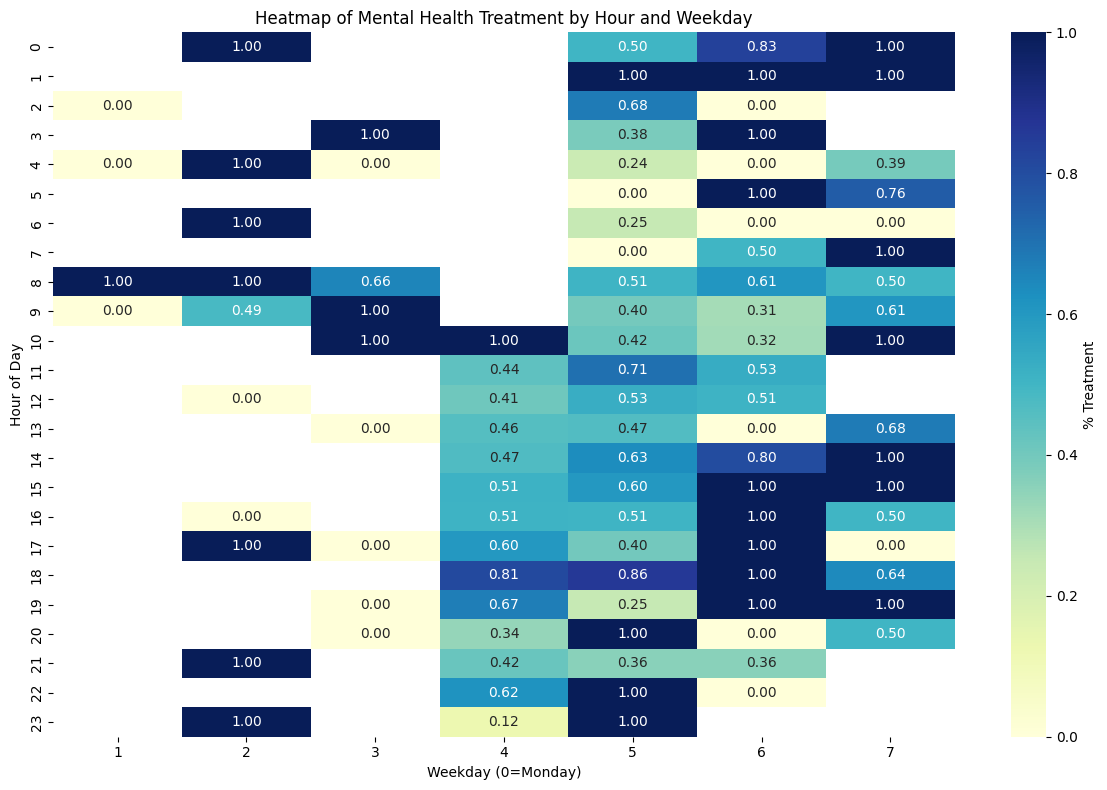

In [25]:
# Risk vs. Time Heatmap: Showing how the proportion of people who have received treatment varies by hour of day and day of week.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Converting PySpark DataFrame to Pandas
df_pd = df_back.select("hour_col", "weekday_col", "treatment").toPandas()

df_pd["treatment"] = df_pd["treatment"].astype(bool)
df_pd["hour_col"] = df_pd["hour_col"].astype(int)
df_pd["weekday_col"] = df_pd["weekday_col"].astype(int)

# Grouping and calculating treatment % per hour and weekday
heatmap_data = (
    df_pd.groupby(["hour_col", "weekday_col"])["treatment"]
    .mean()  # Mean of boolean = % of True
    .reset_index()
    .pivot(index="hour_col", columns="weekday_col", values="treatment")
)

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': '% Treatment'})
plt.title("Heatmap of Mental Health Treatment by Hour and Weekday")
plt.xlabel("Weekday (0=Monday)")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

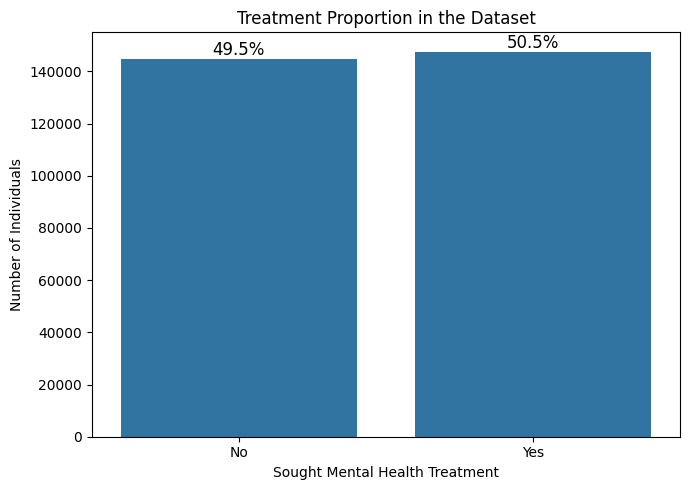

In [26]:
# Risk Score Distribution (Treatment Proportion)
import seaborn as sns
import matplotlib.pyplot as plt

df_pd["treatment"] = df_pd["treatment"].astype(bool)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_pd, x="treatment")

total = len(df_pd)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12)

plt.title("Treatment Proportion in the Dataset")
plt.xlabel("Sought Mental Health Treatment")
plt.ylabel("Number of Individuals")
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()


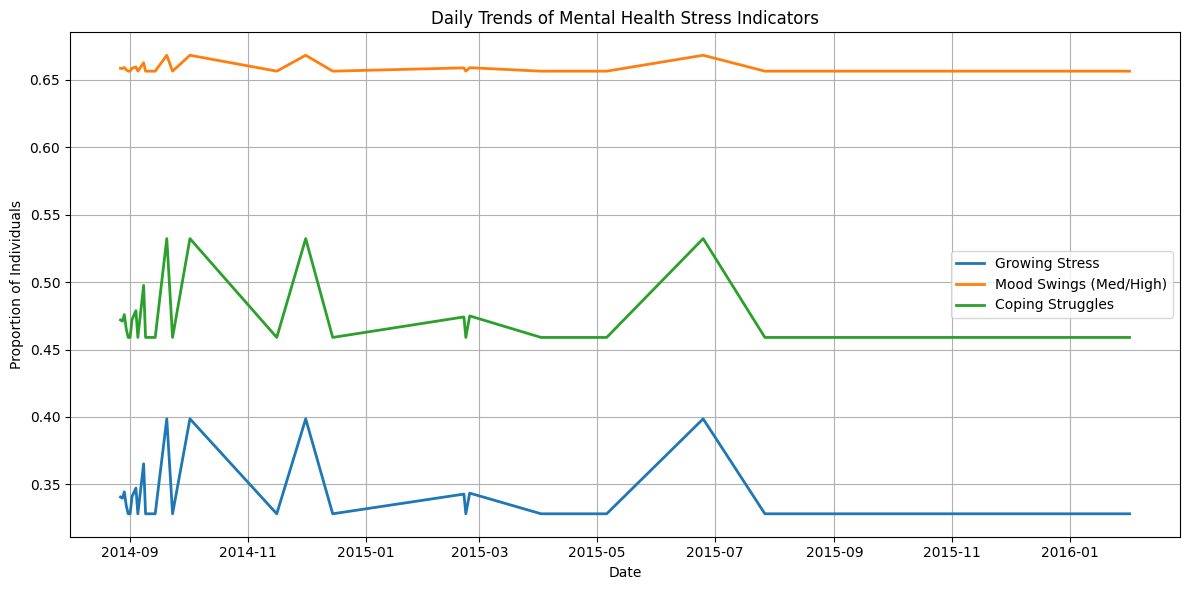

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Selecting relevant columns
df_stress = df_back.select("timestamp", "growing_stress", "mood_swings", "coping_struggles").toPandas()

# Converting timestamp to datetime and extract date only
df_stress["timestamp"] = pd.to_datetime(df_stress["timestamp"])
df_stress["date"] = df_stress["timestamp"].dt.date

# Converting boolean-like columns to actual booleans
df_stress["growing_stress"] = df_stress["growing_stress"].astype(bool)
df_stress["coping_struggles"] = df_stress["coping_struggles"].astype(bool)
# For mood_swings, treat 'medium' or 'high' as stress indicators
df_stress["mood_swings_flag"] = df_stress["mood_swings"].isin(["medium", "high"])

# Grouping by date and calculate proportions
daily_trends = df_stress.groupby("date")[["growing_stress", "mood_swings_flag", "coping_struggles"]].mean()

# Plotting the line graph
plt.figure(figsize=(12, 6))
plt.plot(daily_trends.index, daily_trends["growing_stress"], label="Growing Stress", linewidth=2)
plt.plot(daily_trends.index, daily_trends["mood_swings_flag"], label="Mood Swings (Med/High)", linewidth=2)
plt.plot(daily_trends.index, daily_trends["coping_struggles"], label="Coping Struggles", linewidth=2)

plt.title("Daily Trends of Mental Health Stress Indicators")
plt.xlabel("Date")
plt.ylabel("Proportion of Individuals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
import plotly.express as px

# Selecting relevant columns
df_geo = df_back.select("country", "treatment").toPandas()
df_geo["country"] = df_geo["country"].str.strip().str.title()
df_geo["treatment"] = df_geo["treatment"].astype(bool)

# Grouping by country and calculate treatment percentage
country_risk = (
    df_geo.groupby("country")["treatment"]
    .mean()
    .reset_index()
    .rename(columns={"treatment": "treatment_rate"})
)

# Plotting the choropleth graph
fig = px.choropleth(
    country_risk,
    locations="country",
    locationmode="country names",
    color="treatment_rate",
    color_continuous_scale="YlOrRd",
    title="Mental Health Treatment Rate by Country",
    labels={"treatment_rate": "Treatment Rate"},
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="% Treated"),
)
fig.show()

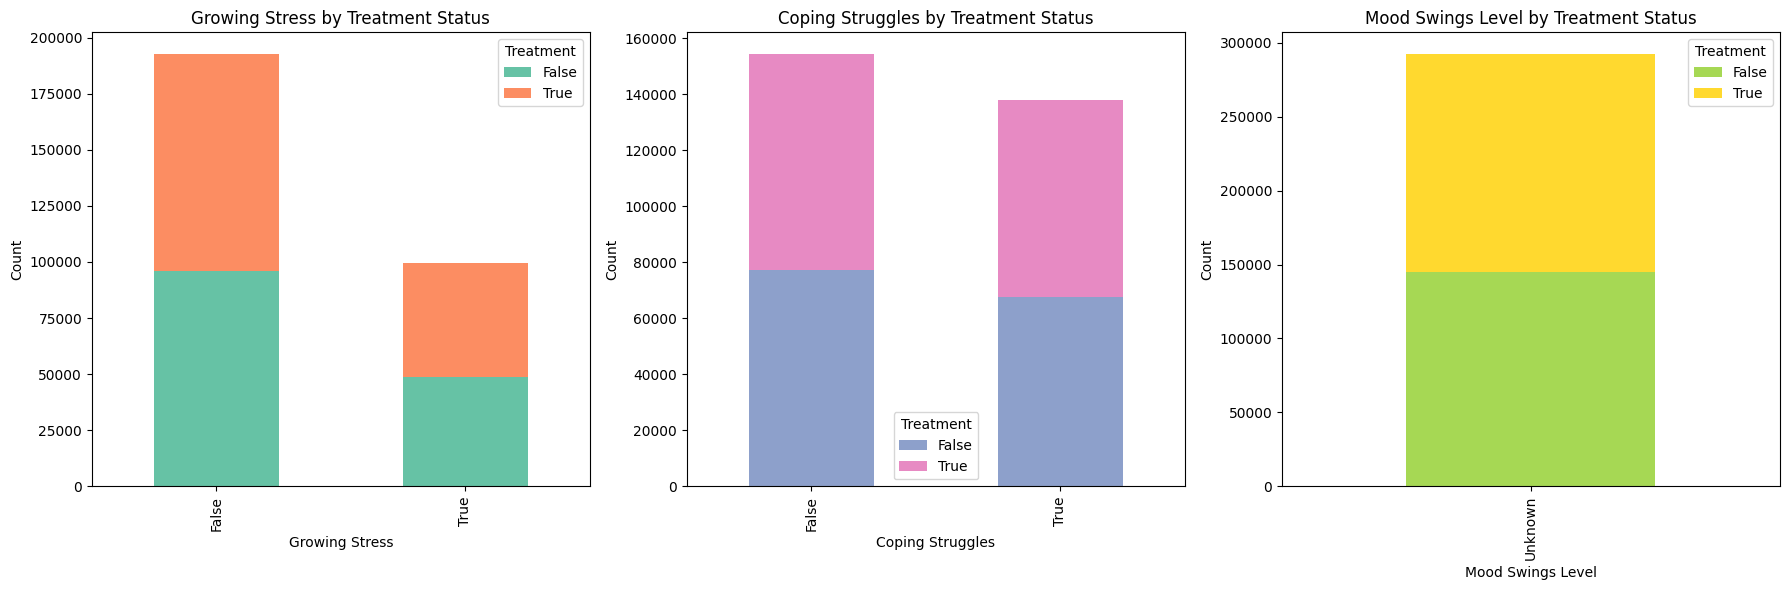

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df_risk = df_back.select("treatment", "growing_stress", "coping_struggles", "mood_swings_level").toPandas()
df_risk["treatment"] = df_risk["treatment"].astype(bool)
df_risk["growing_stress"] = df_risk["growing_stress"].astype(bool)
df_risk["coping_struggles"] = df_risk["coping_struggles"].astype(bool)

mood_map = {"low": "Low", "medium": "Medium", "high": "High"}
df_risk["mood_swings_level"] = df_risk["mood_swings_level"].map(mood_map).fillna("Unknown")

# Growing stress
stress_counts = df_risk.groupby(["treatment", "growing_stress"]).size().unstack().fillna(0)

# Coping struggles
coping_counts = df_risk.groupby(["treatment", "coping_struggles"]).size().unstack().fillna(0)

# Mood swings
mood_counts = df_risk.groupby(["treatment", "mood_swings_level"]).size().unstack().fillna(0)

# Plotting all three side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

stress_counts.T.plot(kind="bar", stacked=True, ax=axes[0], color=["#66c2a5", "#fc8d62"])
axes[0].set_title("Growing Stress by Treatment Status")
axes[0].set_xlabel("Growing Stress")
axes[0].set_ylabel("Count")
axes[0].legend(title="Treatment")

coping_counts.T.plot(kind="bar", stacked=True, ax=axes[1], color=["#8da0cb", "#e78ac3"])
axes[1].set_title("Coping Struggles by Treatment Status")
axes[1].set_xlabel("Coping Struggles")
axes[1].set_ylabel("Count")
axes[1].legend(title="Treatment")

mood_counts.T.plot(kind="bar", stacked=True, ax=axes[2], color=["#a6d854", "#ffd92f"])
axes[2].set_title("Mood Swings Level by Treatment Status")
axes[2].set_xlabel("Mood Swings Level")
axes[2].set_ylabel("Count")
axes[2].legend(title="Treatment")

plt.tight_layout()
plt.show()

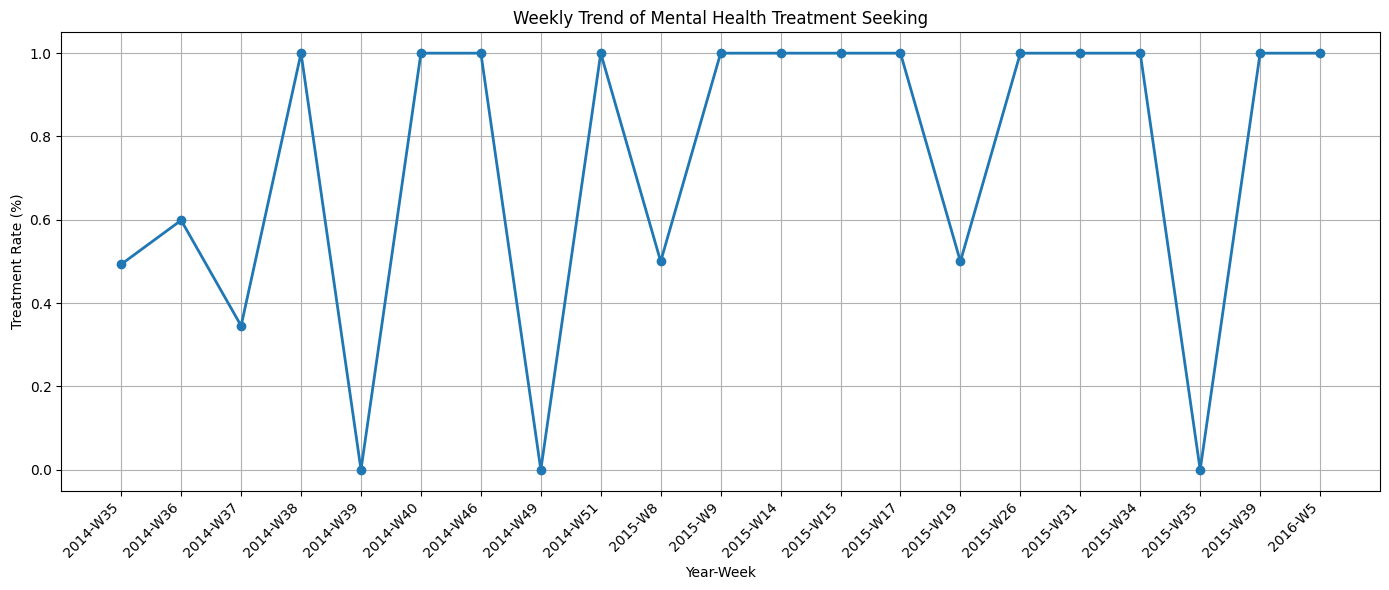

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df_weekly = df_back.select("timestamp", "treatment").toPandas()

# Converting timestamp to datetime
df_weekly["timestamp"] = pd.to_datetime(df_weekly["timestamp"])
df_weekly["treatment"] = df_weekly["treatment"].astype(bool)

# Extracting week and year from timestamp
df_weekly["week"] = df_weekly["timestamp"].dt.isocalendar().week
df_weekly["year"] = df_weekly["timestamp"].dt.year

# Grouping by year-week combination and calculating treatment rate
weekly_treatment = (
    df_weekly.groupby(["year", "week"])["treatment"]
    .mean()
    .reset_index()
    .sort_values(["year", "week"])
)

# Combining year-week into a single label for plotting
weekly_treatment["year_week"] = weekly_treatment["year"].astype(str) + "-W" + weekly_treatment["week"].astype(str)

# Plotting line graph
plt.figure(figsize=(14, 6))
plt.plot(weekly_treatment["year_week"], weekly_treatment["treatment"], marker='o', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title("Weekly Trend of Mental Health Treatment Seeking")
plt.xlabel("Year-Week")
plt.ylabel("Treatment Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

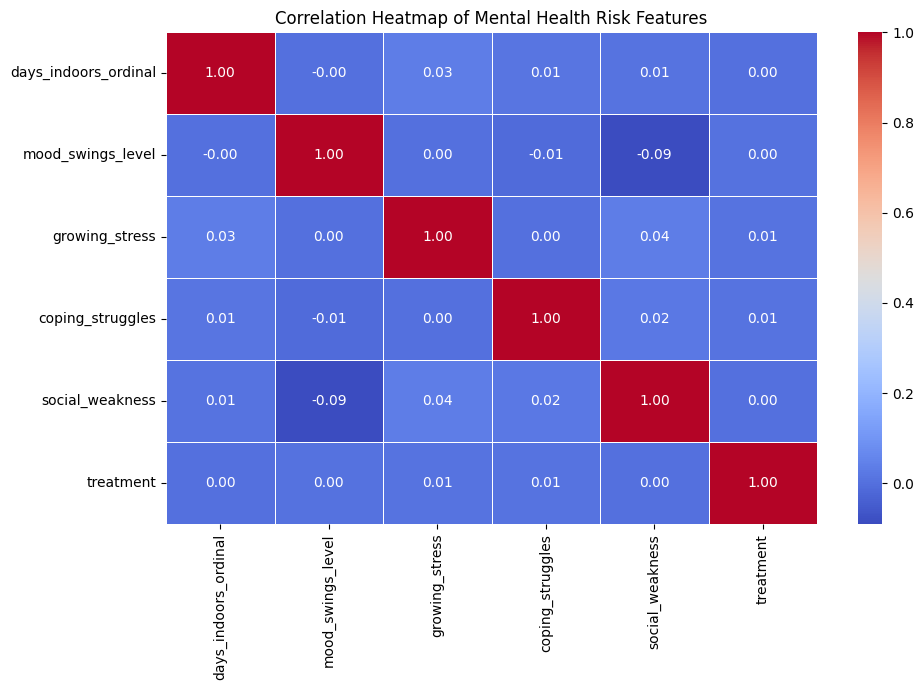

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting relevant columns and convert to pandas
df_corr = df_back.select(
    "days_indoors_ordinal",
    "mood_swings_level",
    "growing_stress",
    "coping_struggles",
    "social_weakness",
    "treatment"
).toPandas()

df_corr["growing_stress"] = df_corr["growing_stress"].astype(bool)
df_corr["coping_struggles"] = df_corr["coping_struggles"].astype(bool)
df_corr["social_weakness"] = df_corr["social_weakness"].astype(bool)
df_corr["treatment"] = df_corr["treatment"].astype(bool)
df_corr = df_corr.astype(int)

if df_corr["mood_swings_level"].dtype == object:
    df_corr["mood_swings_level"] = df_corr["mood_swings_level"].map({"low": 1, "medium": 2, "high": 3})

# Computing correlation matrix
corr_matrix = df_corr.corr()

# Plotting heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Mental Health Risk Features")
plt.tight_layout()
plt.show()

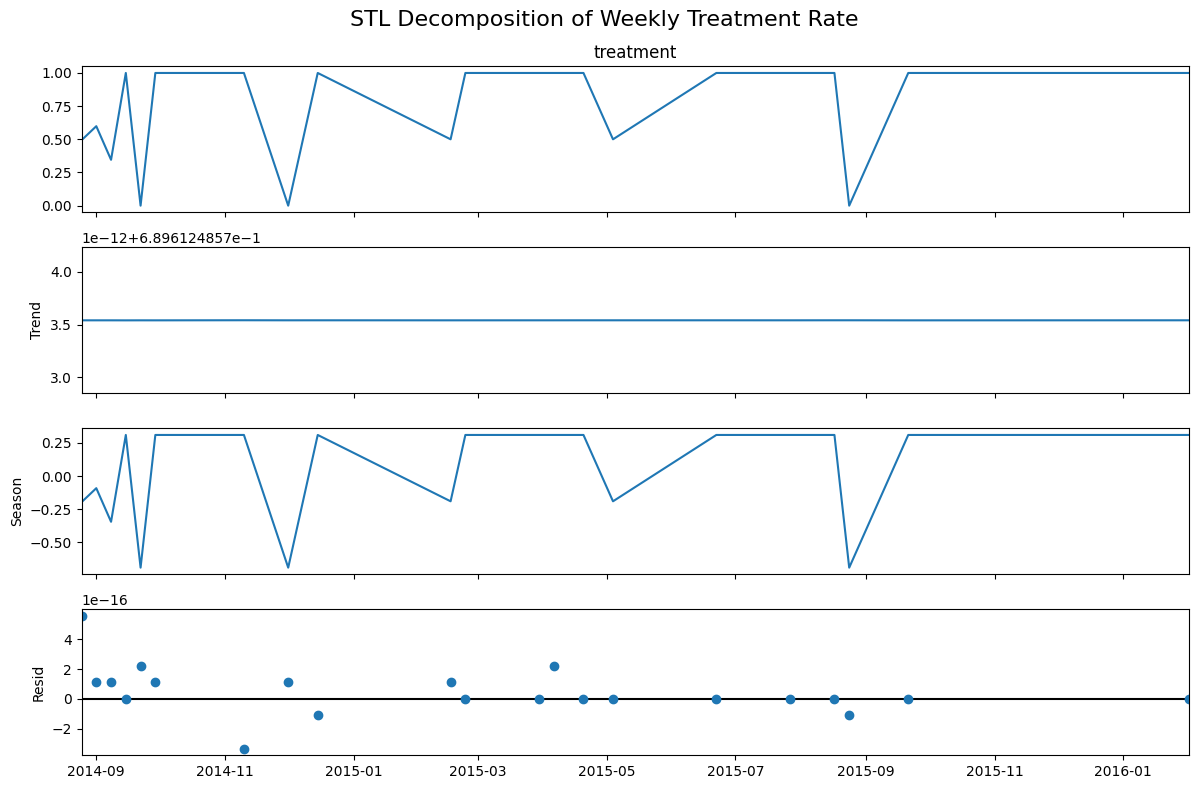

In [32]:
from statsmodels.tsa.seasonal import STL
import pandas as pd
import matplotlib.pyplot as plt

# Preparing weekly time series
df_stl = df_back.select("timestamp", "treatment").toPandas()
df_stl["timestamp"] = pd.to_datetime(df_stl["timestamp"])
df_stl["treatment"] = df_stl["treatment"].astype(bool)
df_stl["date"] = df_stl["timestamp"].dt.to_period("W").dt.start_time  # Weekly periods

# Aggregating weekly treatment rate
weekly_series = df_stl.groupby("date")["treatment"].mean()

# STL decomposition
stl = STL(weekly_series, period=52)  # 52 weeks for yearly seasonality
res = stl.fit()

# Plotting the decomposition
fig = res.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL Decomposition of Weekly Treatment Rate", fontsize=16)
plt.tight_layout()
plt.show()

<ipython-input-33-f35a98e68f70>:18: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-33-f35a98e68f70>:20: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



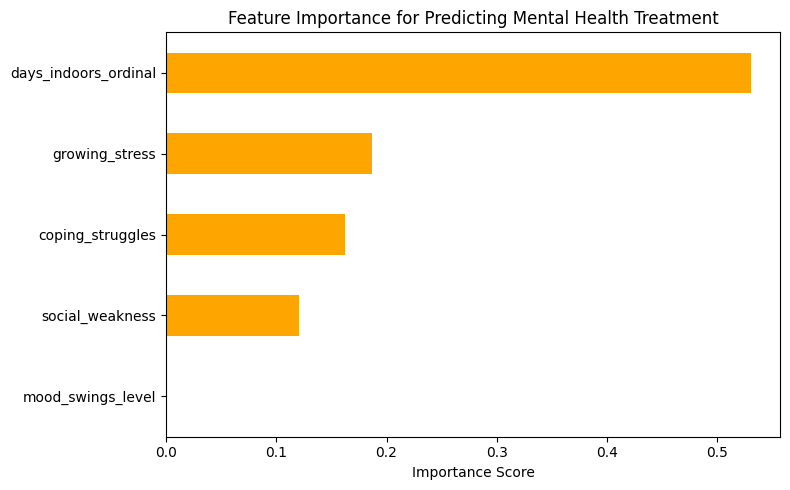

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Loading data from Spark
df_feat = df_back.select(
    "days_indoors_ordinal",
    "mood_swings_level",
    "growing_stress",
    "coping_struggles",
    "social_weakness",
    "treatment"
).toPandas()

# Filling boolean fields with False
df_feat["growing_stress"] = df_feat["growing_stress"].fillna(False)
df_feat["coping_struggles"] = df_feat["coping_struggles"].fillna(False)
df_feat["social_weakness"] = df_feat["social_weakness"].fillna(False)
df_feat["treatment"] = df_feat["treatment"].fillna(False)

df_feat["mood_swings_level"] = df_feat["mood_swings_level"].map({
    "low": 1,
    "medium": 2,
    "high": 3
})
df_feat["mood_swings_level"] = df_feat["mood_swings_level"].fillna(0)  # 0 = unknown

# Filling missing values in days_indoors_ordinal with median
df_feat["days_indoors_ordinal"] = df_feat["days_indoors_ordinal"].fillna(
    df_feat["days_indoors_ordinal"].median()
)
df_feat = df_feat.astype(int)

# Split into features and target
X = df_feat.drop("treatment", axis=1)
y = df_feat["treatment"]

# Train-test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

# Plotting Bar Graph
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='orange')
plt.title("Feature Importance for Predicting Mental Health Treatment")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [36]:
from google.colab import files

# Converting to Pandas
df_final = df_back.toPandas()

print("Pandas DataFrame:")
df_final.head()

# Exporting cleaned and processed feature dataset to CSV
df_final.to_csv("mental_health_processed.csv", index=False)

# Downloading to the system
files.download("mental_health_processed.csv")

Pandas DataFrame:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>